## Imports

In [2]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

## Data

In [3]:
x_train = 2 * torch.rand(200, 3) - 1
x_train

tensor([[ 0.2342, -0.4279, -0.0723],
        [ 0.9550,  0.7684, -0.0991],
        [-0.3029,  0.8199, -0.9120],
        [-0.4076,  0.2386,  0.3202],
        [-0.7556,  0.1046, -0.6504],
        [ 0.7755, -0.8685, -0.8375],
        [-0.4074, -0.2834, -0.7494],
        [-0.4145, -0.2794, -0.1308],
        [ 0.9230, -0.7006, -0.1421],
        [ 0.4365, -0.9986, -0.4178],
        [ 0.1855,  0.6175, -0.6704],
        [-0.4078, -0.6104, -0.1669],
        [-0.0532, -0.8419, -0.6237],
        [-0.3081,  0.4957,  0.8542],
        [-0.2256,  0.8066,  0.9222],
        [ 0.6769,  0.6509,  0.0823],
        [ 0.8046,  0.7806, -0.5147],
        [ 0.6873,  0.7311,  0.3018],
        [-0.2667, -0.6029, -0.2367],
        [ 0.8963,  0.8930, -0.6334],
        [ 0.3591,  0.6072,  0.3138],
        [ 0.2965,  0.1249,  0.3606],
        [ 0.4677,  0.2737, -0.8639],
        [-0.4603,  0.8697, -0.9887],
        [ 0.6606,  0.4953, -0.0498],
        [-0.5564, -0.1438, -0.8474],
        [ 0.6598,  0.0464, -0.6808],
 

In [4]:
y_train = torch.rand(200)
y_train

tensor([3.3169e-01, 2.9015e-01, 4.1889e-01, 2.6952e-01, 9.2523e-01, 4.5718e-01,
        5.4595e-01, 2.4821e-01, 2.8692e-01, 4.3274e-01, 4.9672e-01, 1.5399e-01,
        7.2373e-01, 7.7400e-01, 7.2583e-01, 7.4263e-01, 4.0173e-01, 4.5308e-01,
        1.5971e-01, 9.5110e-01, 7.0743e-01, 6.1612e-01, 7.3033e-01, 8.1581e-01,
        9.9371e-01, 5.9967e-01, 4.6811e-01, 2.7343e-01, 8.0313e-01, 6.9154e-01,
        3.8966e-02, 7.0270e-01, 2.7012e-01, 5.3495e-01, 4.2615e-01, 1.6298e-01,
        4.3276e-01, 5.5060e-01, 2.5777e-01, 6.4913e-01, 6.0994e-01, 3.0889e-01,
        3.4122e-01, 2.2082e-01, 8.6405e-01, 3.4870e-01, 6.3621e-02, 2.9019e-01,
        5.8372e-01, 3.4781e-01, 3.3162e-01, 2.9542e-01, 3.7515e-01, 6.2206e-01,
        2.2003e-01, 4.5546e-01, 2.5071e-01, 4.8452e-01, 6.7244e-02, 7.1020e-01,
        3.9613e-01, 9.4864e-01, 2.6243e-01, 1.9891e-01, 8.9163e-01, 6.1960e-01,
        6.7341e-02, 8.4953e-01, 5.1339e-01, 6.4051e-01, 1.7202e-01, 7.8238e-01,
        7.0340e-01, 8.0720e-01, 5.7480e-

## Model

In [5]:
mf_distribution = [3, 2, 3]

In [384]:
model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
)

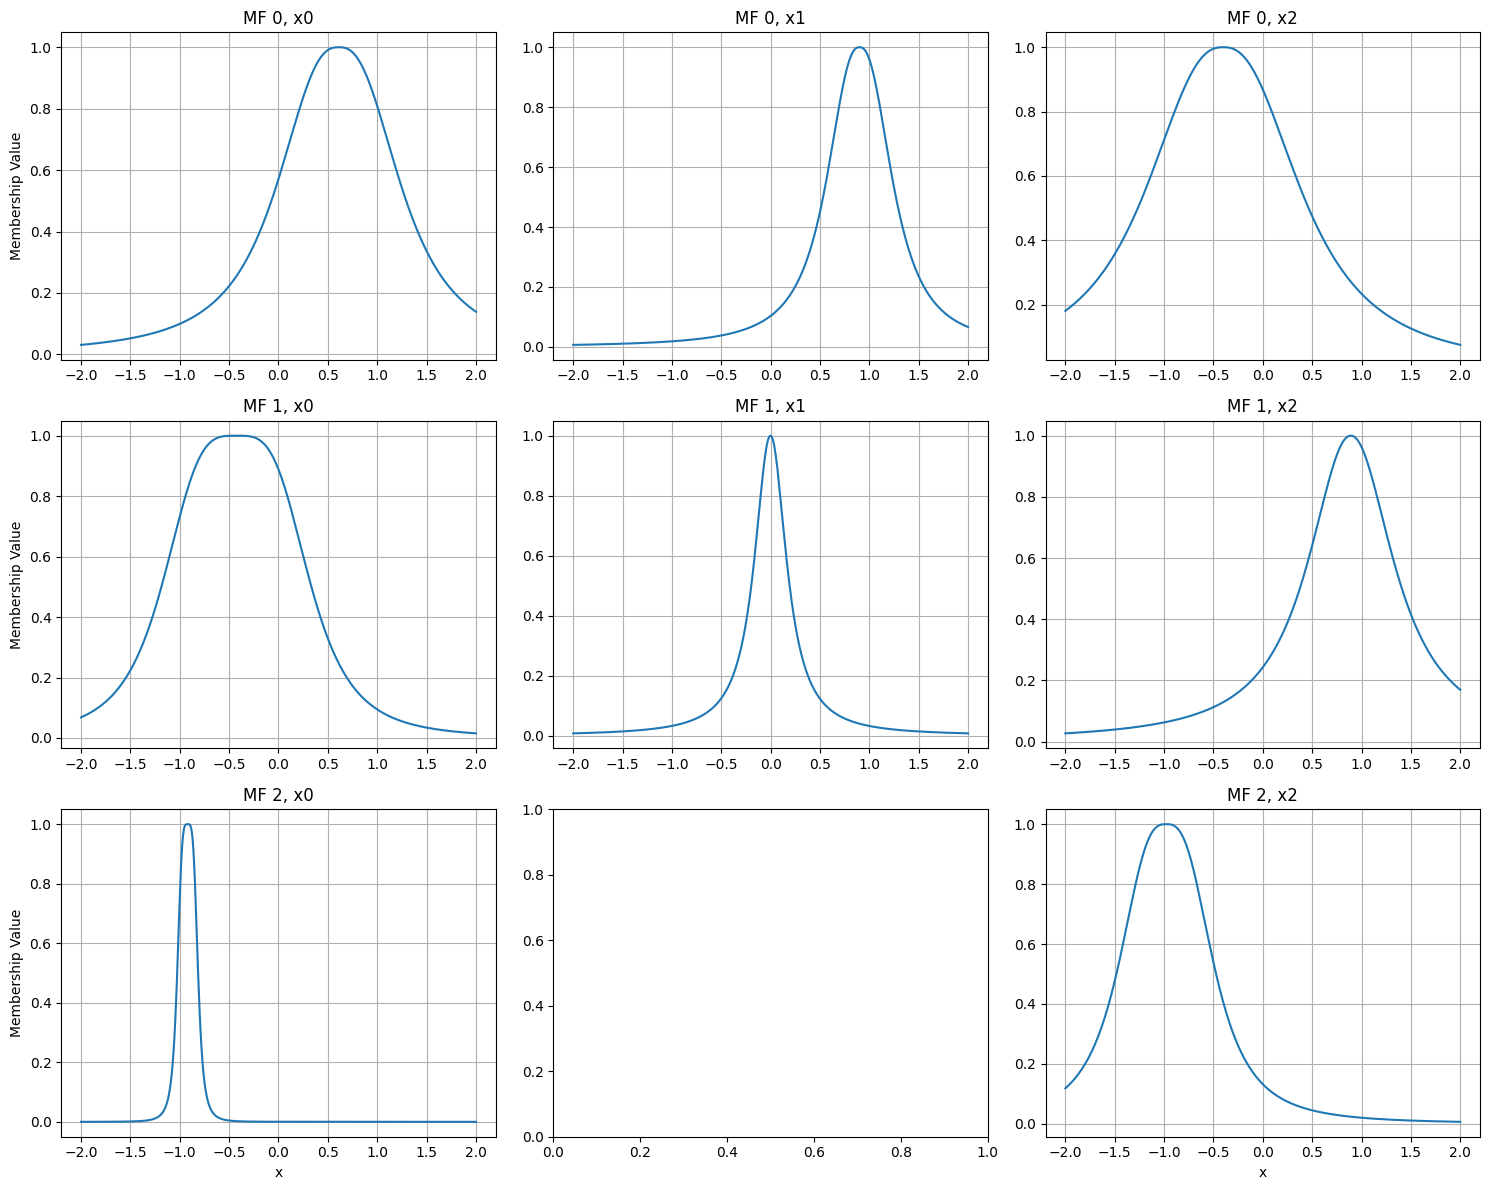

In [385]:
model.plot_premises()

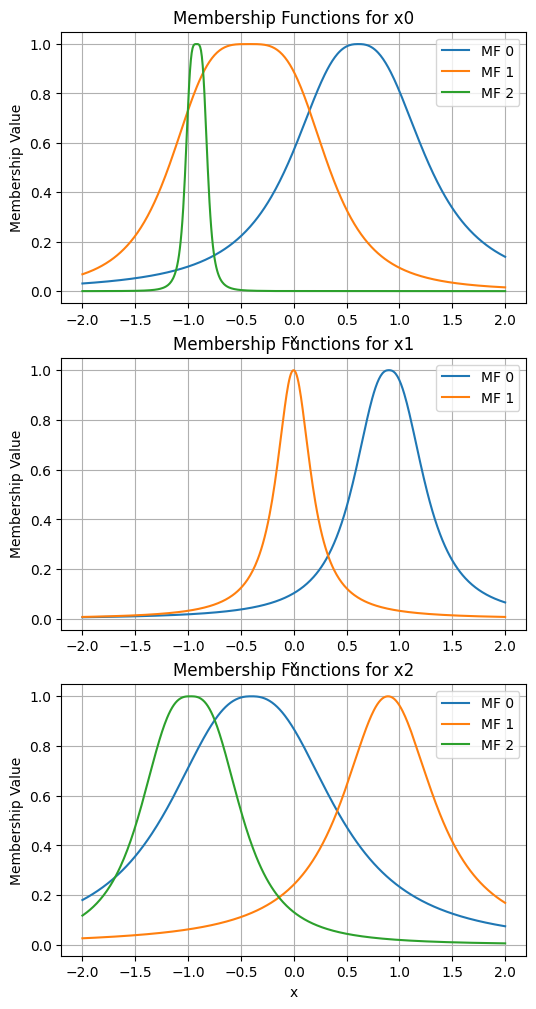

In [386]:
model.plot_premises(group_by_dim=True)

In [387]:
model.init_premises(x_train)

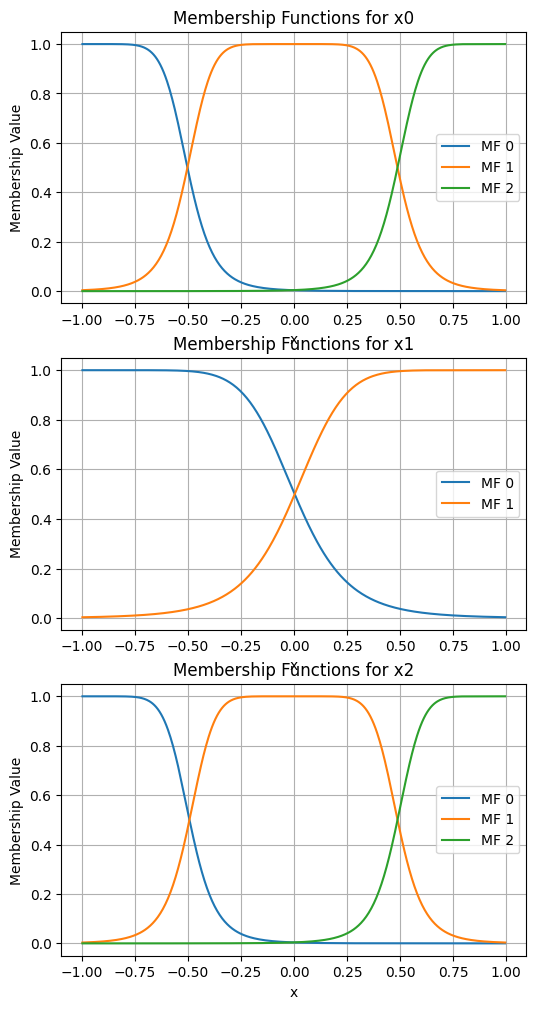

In [388]:
model.plot_premises(group_by_dim=True)

In [389]:
model.show_premises_structure()

        a (x0)  b (x0)    c (x0)    a (x1)  b (x1)    c (x1)   a (x2)  b (x2)  \
MF 0  0.495136     4.0 -0.998107  0.991933     4.0 -0.989245  0.49041     4.0   
MF 1  0.495136     4.0 -0.007836  0.991933     4.0  0.994620  0.49041     4.0   
MF 2  0.495136     4.0  0.982435       NaN     NaN       NaN  0.49041     4.0   

        c (x2)  
MF 0 -0.983775  
MF 1 -0.002956  
MF 2  0.977864  


In [390]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1),a (x2),b (x2),c (x2)
MF 0,0.495136,4.0,-0.998107,0.991933,4.0,-0.989245,0.49041,4.0,-0.983775
MF 1,0.495136,4.0,-0.007836,0.991933,4.0,0.994620,0.49041,4.0,-0.002956
MF 2,0.495136,4.0,0.982435,NaN,NaN,NaN,0.49041,4.0,0.977864


In [391]:
model.get_premises()

[tensor([[ 0.4951,  4.0000, -0.9981],
         [ 0.4951,  4.0000, -0.0078],
         [ 0.4951,  4.0000,  0.9824]]),
 tensor([[ 0.9919,  4.0000, -0.9892],
         [ 0.9919,  4.0000,  0.9946]]),
 tensor([[ 4.9041e-01,  4.0000e+00, -9.8378e-01],
         [ 4.9041e-01,  4.0000e+00, -2.9557e-03],
         [ 4.9041e-01,  4.0000e+00,  9.7786e-01]])]

## Binary output

In [392]:
x_train = 2 * torch.rand(200, 3) - 1

In [393]:
x_train[:10]

tensor([[ 0.3548,  0.5002,  0.9277],
        [ 0.9634, -0.8925,  0.3776],
        [-0.2472,  0.4155,  0.6998],
        [-0.8156, -0.8858, -0.8581],
        [-0.7510, -0.3350,  0.7338],
        [ 0.3599, -0.2020,  0.4650],
        [ 0.3146,  0.2245,  0.1090],
        [ 0.6138,  0.0325, -0.4810],
        [ 0.4188,  0.1325, -0.1735],
        [ 0.8298, -0.5847,  0.8245]])

In [394]:
mf_distribution

[3, 2, 3]

In [395]:
bin_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    output_type='binary', # Tipo de salida: clasificación binaria
)

In [396]:
bin_model.get_premises()

[tensor([[ 0.3861,  1.1781, -0.4510],
         [ 0.4011,  1.9416,  0.2481],
         [ 0.1975,  1.1856, -0.7613]]),
 tensor([[ 0.0240,  1.0577, -0.0656],
         [ 0.9577,  1.2237, -0.0230]]),
 tensor([[ 0.0562,  1.8837,  0.3307],
         [ 0.8264,  1.1510,  0.2530],
         [ 0.3645,  1.7966, -0.1036]])]

In [397]:
bin_model.get_consequents()

tensor([[[-0.4142,  0.5191, -0.9141,  0.6919],
         [-0.5222,  0.8171,  0.7787, -0.8418],
         [ 0.0828,  0.3983,  0.6923,  0.7140],
         [-0.3237, -0.6849, -0.4792,  0.4211],
         [ 0.7561, -0.5646, -0.7450, -0.5317],
         [-0.6904, -0.0300, -0.7538,  0.6912],
         [-0.1964,  0.3681,  0.8341, -0.3370],
         [ 0.9417,  0.4819, -0.5299,  0.1836],
         [-0.6022, -0.0412, -0.1553,  0.3791],
         [-0.7625,  0.2506, -0.2200, -0.5421],
         [-0.7212, -0.5095, -0.5840, -0.6210],
         [ 0.8169,  0.9520,  0.9819,  0.2435],
         [-0.3506, -0.2987, -0.0883, -0.6475],
         [ 0.9019,  0.1969,  0.5296,  0.6441],
         [ 0.5979,  0.4829,  0.8831, -0.6042],
         [ 0.7457,  0.6318,  0.4892,  0.3702],
         [ 0.5654, -0.6533,  0.6482,  0.9613],
         [-0.0411,  0.5795, -0.4764, -0.4232]]])

In [398]:
bin_model(x_train[:10])

tensor([0.1892, 0.3760, 0.2551, 0.5839, 0.5352, 0.3360, 0.4658, 0.4577, 0.4857,
        0.2792], grad_fn=<SigmoidBackward0>)

In [399]:
bin_model.predict(x_train[:10])

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0])

## Multiclass output

In [400]:
x_train = 2 * torch.rand(200, 3) - 1

In [401]:
mul_class_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    outputs=3, # 3 clases
    output_type='multiclass', # Tipo de salida: clasificación multiclase
)

In [402]:
mul_class_model(x_train[:10])

tensor([[ 0.1540,  0.0939,  0.2426],
        [-0.5684, -1.1335, -0.6306],
        [ 0.3715, -0.6234, -0.8917],
        [ 0.1403, -0.0185, -0.0422],
        [ 0.1061,  0.5803,  0.2461],
        [ 0.4154,  0.2090,  0.1386],
        [ 0.0684, -0.3463, -1.0440],
        [ 0.5045,  0.0111, -0.3665],
        [ 0.7300,  0.3041, -0.6382],
        [ 0.4923,  0.1150,  0.0087]], grad_fn=<SqueezeBackward1>)

In [403]:
mul_class_model(x_train[:10], return_probabilities=True)

tensor([[0.3296, 0.3103, 0.3601],
        [0.3987, 0.2266, 0.3747],
        [0.6051, 0.2238, 0.1711],
        [0.3723, 0.3176, 0.3101],
        [0.2662, 0.4277, 0.3062],
        [0.3888, 0.3163, 0.2948],
        [0.5027, 0.3320, 0.1653],
        [0.4928, 0.3009, 0.2063],
        [0.5242, 0.3424, 0.1334],
        [0.4344, 0.2978, 0.2678]], grad_fn=<SoftmaxBackward0>)

In [404]:
mul_class_model.predict(x_train[:10])

array([2, 0, 0, 0, 1, 0, 0, 0, 0, 0])